<a href="https://colab.research.google.com/github/duanfafner/haruandchar/blob/main/Survival_and_Discrete_Choice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SU25:Data Analytics For Business

Homework 3 - Part 1 Survival Models

Dataset: Bank Attrition

In [ ]:
library(readr)
library(dplyr)
library(ggplot2)
library(tidyverse)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
bank_data <- read.csv("Bank_Attrition.csv")
summary(bank_data)
head(bank_data, 10)

   CustomerID        Age           Income          HomeVal      
 Min.   :   1   Min.   :21.0   Min.   : 0.500   Min.   :  1.30  
 1st Qu.: 627   1st Qu.:47.0   1st Qu.: 5.300   1st Qu.: 18.70  
 Median :1253   Median :57.0   Median : 7.500   Median : 22.50  
 Mean   :1253   Mean   :55.5   Mean   : 8.511   Mean   : 27.21  
 3rd Qu.:1879   3rd Qu.:67.0   3rd Qu.:11.500   3rd Qu.: 27.50  
 Max.   :2505   Max.   :77.0   Max.   :15.000   Max.   :150.00  
     Tenure       DirectDeposit         Loan         NumAccounts    
 Min.   : 0.000   Min.   :0.0000   Min.   :0.0000   Min.   : 1.000  
 1st Qu.: 8.646   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.: 2.000  
 Median :14.664   Median :1.0000   Median :0.0000   Median : 3.000  
 Mean   :16.037   Mean   :0.6379   Mean   :0.2527   Mean   : 2.922  
 3rd Qu.:21.736   3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.: 4.000  
 Max.   :59.937   Max.   :1.0000   Max.   :1.0000   Max.   :11.000  
      Dist            MktShare          ChurnTime         Cens

,CustomerID,Age,Income,HomeVal,Tenure,DirectDeposit,Loan,NumAccounts,Dist,MktShare,ChurnTime,Censored
,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>
1,1,62,4.8,27.5,2.529774,0,0,2,1.302308,0.02913851,5.0,0
2,2,47,15.0,47.5,2.809035,0,0,2,1.302308,0.02913851,5.2,0
3,3,42,3.8,18.7,2.748802,0,0,2,1.302308,0.02913851,4.2,0
4,4,47,7.5,55.0,8.010951,0,1,3,1.302308,0.02913851,0.1,0
5,5,67,15.0,95.0,11.003422,0,1,3,3.516000,0.02913851,12.5,0
6,6,57,15.0,37.5,2.759754,0,0,1,6.602500,0.02913851,5.4,0
7,7,52,9.5,37.5,11.208761,1,0,2,1.302308,0.02913851,8.4,0
8,8,70,4.8,11.3,15.934292,0,0,1,1.302308,0.02913851,4.2,0
9,9,77,15.0,95.0,11.518138,0,1,4,4.561111,0.01089193,2.8,1


In [ ]:

# Load required libraries
library(survival)


In [ ]:
surv_object <- Surv(time = bank_data$ChurnTime,
                    event = 1- bank_data$Censored)


In [ ]:
weibull_model <- survreg(surv_object ~ Age + Income + HomeVal + Tenure +
                         DirectDeposit + Loan + NumAccounts + Dist + MktShare,
                         data = bank_data,
                         dist = "weibull")

summary(weibull_model)


Call:
survreg(formula = surv_object ~ Age + Income + HomeVal + Tenure + 
    DirectDeposit + Loan + NumAccounts + Dist + MktShare, data = bank_data, 
    dist = "weibull")
                  Value Std. Error      z       p
(Intercept)    2.082330   0.056983  36.54 < 2e-16
Age            0.002568   0.000748   3.43  0.0006
Income        -0.008737   0.002682  -3.26  0.0011
HomeVal        0.000507   0.000561   0.90  0.3660
Tenure         0.004110   0.001038   3.96 7.5e-05
DirectDeposit  0.054730   0.021014   2.60  0.0092
Loan          -0.015452   0.028043  -0.55  0.5816
NumAccounts    0.005422   0.008708   0.62  0.5335
Dist          -0.006569   0.011971  -0.55  0.5832
MktShare       0.007986   0.059472   0.13  0.8932
Log(scale)    -0.813206   0.017582 -46.25 < 2e-16

Scale= 0.443 

Weibull distribution
Loglik(model)= -5891.7   Loglik(intercept only)= -5931
	Chisq= 78.55 on 9 degrees of freedom, p= 3.1e-13 
Number of Newton-Raphson Iterations: 7 
n= 2505 


In [ ]:
# Extract the reported estimates
delta_estimates <- coef(weibull_model)
scale_estimate <- weibull_model$scale

In [ ]:
# Transform to β estimates (proportional hazards parameterization)
# β = -δ/scale
beta_estimates <- -delta_estimates / scale_estimate

print(beta_estimates)

# β (PH) estimates - after transformation:

# Positive β: Variable increases hazard rate (increases churn risk)
# Negative β: Variable decreases hazard rate (decreases churn risk)
# exp(β) gives hazard ratios



  (Intercept)           Age        Income       HomeVal        Tenure 
 -4.695917470  -0.005791709   0.019704049  -0.001144367  -0.009267927 
DirectDeposit          Loan   NumAccounts          Dist      MktShare 
 -0.123423346   0.034846367  -0.012227870   0.014813675  -0.018009854 


In [ ]:
# Transform to shape parameter a
# a = 1/scale
shape_parameter_a <- 1 / scale_estimate
print(shape_parameter_a )
#a > 1: Hazard rate increases over time  Customers are more likely to churn as time goes on
#a < 1: Hazard rate decreases over time
#a = 1: Constant hazard rate (exponential distribution)

[1] 2.255127


In [ ]:
hazard_ratios <- exp(beta_estimates)
cat("\n\nHAZARD RATIOS [exp(β)]:")
print(round(hazard_ratios, 4))



HAZARD RATIOS [exp(β)]:  (Intercept)           Age        Income       HomeVal        Tenure 
       0.0091        0.9942        1.0199        0.9989        0.9908 
DirectDeposit          Loan   NumAccounts          Dist      MktShare 
       0.8839        1.0355        0.9878        1.0149        0.9822 


In [ ]:
xbar <- colMeans(bank_data[,2:4])
beta <-coef(weibull_model)*shape_parameter_a



In [ ]:
mean_customer <- data.frame(
  Age = mean(bank_data$Age),
  Income = mean(bank_data$Income),
  HomeVal = mean(bank_data$HomeVal),
  Tenure = mean(bank_data$Tenure),
  DirectDeposit = mean(bank_data$DirectDeposit),
  Loan = mean(bank_data$Loan),
  NumAccounts = mean(bank_data$NumAccounts),
  Dist = mean(bank_data$Dist),
  MktShare = mean(bank_data$MktShare)
)

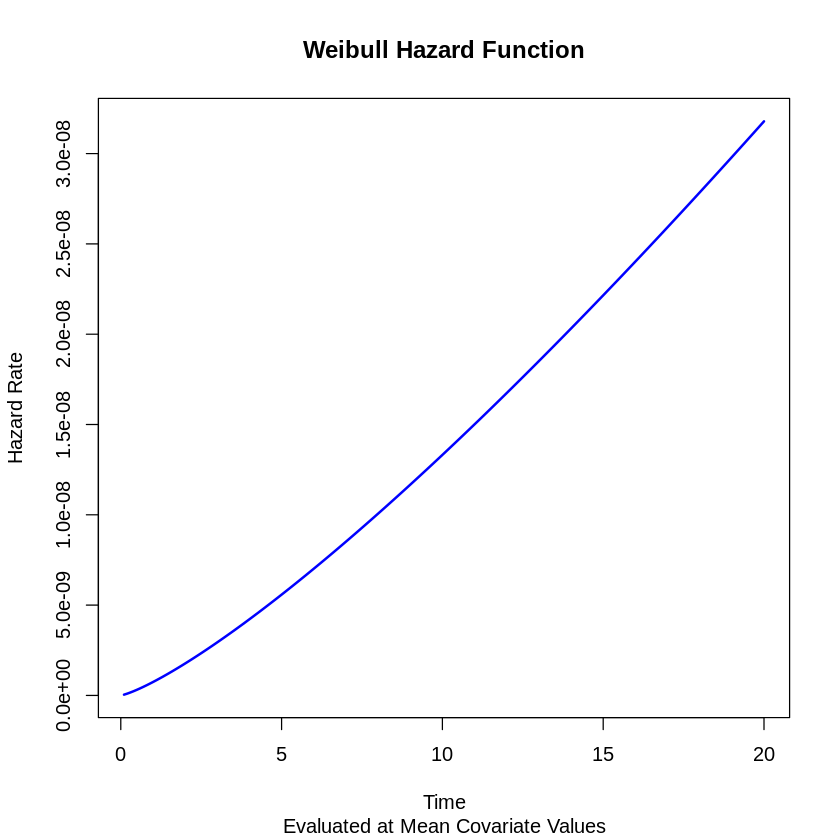

In [ ]:
log_scale_pred <- predict(weibull_model, newdata = mean_customer)
scale_pred <- exp(log_scale_pred)

# Shape parameter
shape_a <- 1 / weibull_model$scale

# Create time sequence
time_seq <- seq(0.1, 20, length.out = 200)

# Calculate hazard function: h(t) = (a/scale) * (t/scale)^(a-1)
hazard_rates <- (shape_a / scale_pred) * (time_seq / scale_pred)^(shape_a - 1)

# Plot
plot(time_seq, hazard_rates,
     type = "l", lwd = 2, col = "blue",
     xlab = "Time", ylab = "Hazard Rate",
     main = "Weibull Hazard Function",
     sub = "Evaluated at Mean Covariate Values")

In [ ]:
# Extract uncensored observations (those who actually churned)
uncensored_data <- bank_data[bank_data$Censored == 0, ]
uncensored_churn_times <- uncensored_data$ChurnTime

Warning message in plot.window(xlim, ylim, "", ...):
“"alpha" is not a graphical parameter”
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
“"alpha" is not a graphical parameter”
Warning message in axis(1, ...):
“"alpha" is not a graphical parameter”
Warning message in axis(2, at = yt, ...):
“"alpha" is not a graphical parameter”


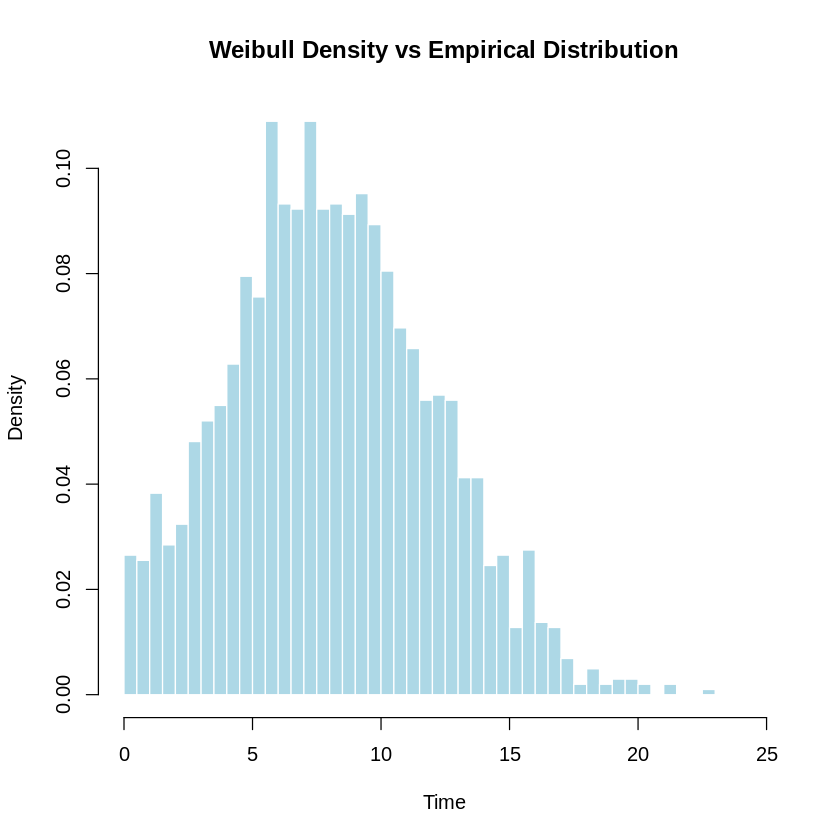

In [ ]:
# Create histogram of uncensored ChurnTime (density scale)
hist(uncensored_churn_times, breaks = 50, freq = FALSE,
     col = "lightblue", border = "white", alpha = 0.7,
     xlab = "Time", ylab = "Density",
     main = "Weibull Density vs Empirical Distribution",
     xlim = c(0, max(uncensored_churn_times) + 2))



SU25:Data Analytics For Business

Homework 3 - Part 2 Discrete Choice Models

Dataset: Commute Mode

In [ ]:
install.packages("mlogit")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘dfidx’, ‘Formula’, ‘zoo’, ‘lmtest’, ‘statmod’, ‘Rdpack’




In [ ]:
commute_data <- read.csv("Commute_Mode.csv")
summary(commute_data)
head(commute_data, 10)

       id          mode               choice          cost       
 Min.   :  1   Length:1812        Min.   :0.00   Min.   :0.1293  
 1st Qu.:114   Class :character   1st Qu.:0.00   1st Qu.:1.7979  
 Median :227   Mode  :character   Median :0.00   Median :2.2493  
 Mean   :227                      Mean   :0.25   Mean   :2.7018  
 3rd Qu.:340                      3rd Qu.:0.25   3rd Qu.:2.8983  
 Max.   :453                      Max.   :1.00   Max.   :8.8555  
      time       
 Min.   : 1.969  
 1st Qu.:26.470  
 Median :40.030  
 Mean   :39.061  
 3rd Qu.:52.061  
 Max.   :75.681  

,id,mode,choice,cost,time
,<int>,<chr>,<int>,<dbl>,<dbl>
1,1,bus,0,1.800512,20.86779
2,1,car,1,1.507010,18.50320
3,1,carpool,0,2.335612,26.33823
4,1,rail,0,2.358920,30.03347
5,2,bus,0,2.237128,67.18189
6,2,car,0,6.056998,31.31111
7,2,carpool,0,2.896919,34.25696
8,2,rail,1,1.855450,60.29313
9,3,bus,0,2.576385,63.30906


In [ ]:
library(mlogit)



In [ ]:
commute_mlogit <- mlogit.data(commute_data,
                               choice = "choice",
                              shape = "long",
                              alt.var = "mode",
                              id.var = "id")
summary(commute_mlogit)

       id           mode       choice             cost             time       
 Min.   :  1   bus    :453   Mode :logical   Min.   :0.1293   Min.   : 1.969  
 1st Qu.:114   car    :453   FALSE:1359      1st Qu.:1.7979   1st Qu.:26.470  
 Median :227   carpool:453   TRUE :453       Median :2.2493   Median :40.030  
 Mean   :227   rail   :453                   Mean   :2.7018   Mean   :39.061  
 3rd Qu.:340                                 3rd Qu.:2.8983   3rd Qu.:52.061  
 Max.   :453                                 Max.   :8.8555   Max.   :75.681  
      id1        idx.chid        idx.alt   
 Min.   :  1   Min.   :  1    bus    :453  
 1st Qu.:114   1st Qu.:114    car    :453  
 Median :227   Median :227    carpool:453  
 Mean   :227   Mean   :227    rail   :453  
 3rd Qu.:340   3rd Qu.:340    NA           
 Max.   :453   Max.   :453    NA           

In [ ]:

model <- mlogit(choice ~ cost + time, data = commute_mlogit)
summary(model)


Call:
mlogit(formula = choice ~ cost + time, data = commute_mlogit, 
    method = "nr")

Frequencies of alternatives:choice
    bus     car carpool    rail 
0.17881 0.48124 0.07064 0.26932 

nr method
5 iterations, 0h:0m:0s 
g'(-H)^-1g = 6.07E-07 
gradient close to zero 

Coefficients :
                      Estimate Std. Error  z-value  Pr(>|z|)    
(Intercept):car      3.2924661  0.3172767  10.3773 < 2.2e-16 ***
(Intercept):carpool -0.9051585  0.2459427  -3.6804 0.0002329 ***
(Intercept):rail     0.6277690  0.1633612   3.8428 0.0001216 ***
cost                -0.7723478  0.0919795  -8.3970 < 2.2e-16 ***
time                -0.0853574  0.0077484 -11.0161 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Log-Likelihood: -354.45
McFadden R^2:  0.34811 
Likelihood ratio test : chisq = 378.56 (p.value = < 2.22e-16)

In [ ]:
head(fitted(model, outcome = FALSE))


,bus,car,carpool,rail
1,0.023239855,0.9599263,0.003898082,0.012935746
2,0.025219334,0.7587305,0.101824644,0.114225571
3,0.010361942,0.7531561,0.179627373,0.056854613
4,0.051006926,0.8205847,0.005177723,0.123230683
5,0.001192494,0.9824974,0.013929585,0.002380538
6,0.108646984,0.7272479,0.153758333,0.010346785


In [ ]:
mean_cost_by_mode <- tapply(commute_data$cost, commute_data$mode, mean)
mean_time_by_mode <- tapply(commute_data$time, commute_data$mode, mean)

print("Mean cost by mode (using tapply):")
print(round(mean_cost_by_mode, 4))

print("Mean time by mode (using tapply):")
print(round(mean_time_by_mode, 4))


[1] "Mean cost by mode (using tapply):"
    bus     car carpool    rail 
 2.0357  4.8735  1.6863  2.2117 
[1] "Mean time by mode (using tapply):"
    bus     car carpool    rail 
39.9234 37.0441 39.7710 39.5045 
